# Bonus: El Modelo A en PyTorch

## Bootcamp Python - PY4
## Módulo 3: Deep Learning y NLP

En la industria y en
la investigación, hoy en día **PyTorch** es, en muchos contextos, la
librería más usada para Deep Learning, más incluso que TensorFlow/Keras.

Entonces, ¿por qué usamos Keras en las sesiones principales? Básicamente
porque su API de alto nivel (`Sequential`, `Dense`, `compile`, `fit`) nos
permitió enfocarnos en las decisiones de arquitectura (Modelo A, B, C) sin
perder tiempo de clase escribiendo un loop de entrenamiento a mano. Pero como
en el Notebook 1 ya abrimos la caja y entendimos a mano qué es una neurona,
qué es el forward pass, y tuvimos una primera intuición de cómo se ajustan
los pesos, ahora estamos en condiciones de ver cómo se ve exactamente lo
mismo en PyTorch.

En este notebook vamos a reconstruir el **Modelo A - El Minimalista** (la
misma arquitectura del Notebook 1: una capa oculta de 8 neuronas), pero esta
vez en PyTorch, para comparar ambos enfoques lado a lado.

### Lo que vamos a hacer:

1. Preparar los mismos datos de siempre (Customer Churn).
2. Ver cómo se define un modelo en PyTorch (muy parecido a Keras, con una
   diferencia importante en cómo se escribe).
3. Escribir el loop de entrenamiento a mano: acá está la diferencia más
   grande con Keras. En Keras, `model.fit()` hace esto por nosotros; en
   PyTorch, lo escribimos explícitamente. Vamos a ver que esto conecta
   directamente con lo que discutimos conceptualmente en el Notebook 1 sobre
   backpropagation y gradient descent.
4. Entrenar, graficar las curvas, y evaluar sobre test.
5. Cerrar con una comparación directa: qué se parece, qué cambia, y cuándo
   conviene usar cada librería.


## 0. Preparando los datos

Repetimos, igual que en los notebooks anteriores, la carga y preparación del
dataset de Customer Churn. No nos detenemos a explicar estos pasos de nuevo
(ya los vimos en detalle en el Notebook 1).

La única diferencia es que ahora, en vez de importar Keras, importamos
`torch`.


In [1]:
# Importamos las librerias de manejo de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Importamos PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Fijamos semillas para reproducibilidad
np.random.seed(42)
torch.manual_seed(42)


In [2]:
# Cargamos y limpiamos el dataset de Customer Churn, igual que siempre
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

data = df.copy()
data = data.drop(columns=["customerID"])
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")
data = data.dropna(subset=["TotalCharges"])

data["Churn"] = data["Churn"].map({"Yes": 1, "No": 0})
X = data.drop(columns=["Churn"])
y = data["Churn"]
X = pd.get_dummies(X, drop_first=True)

# Separamos en train, validation y test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

# Scaling: ajustamos con train y aplicamos a val y test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

n_features = X_train_scaled.shape[1]
print("Features de entrada:", n_features)
print("Tamano de train:", X_train_scaled.shape)
print("Tamano de validation:", X_val_scaled.shape)
print("Tamano de test:", X_test_scaled.shape)


Features de entrada: 30
Tamano de train: (4500, 30)
Tamano de validation: (1125, 30)
Tamano de test: (1407, 30)


### De numpy a tensores de PyTorch

En Keras, le pasábamos a `model.fit()` directamente arrays de numpy. En
PyTorch, los datos tienen que estar en formato **tensor**: la estructura de
datos propia de PyTorch, muy parecida a un array de numpy, pero con la
capacidad extra de que PyTorch puede rastrear automáticamente las operaciones
que se hacen con ellos, para más adelante poder calcular gradientes (esto es
lo que hace posible `loss.backward()`, que vamos a ver más abajo).

Convertimos nuestros arrays de numpy a tensores con `torch.tensor(...)`, y
nos aseguramos de que sean de tipo `float32`, que es lo que espera PyTorch.


In [3]:
# Convertimos los datos de numpy a tensores de PyTorch
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

print("Forma de X_train_tensor:", X_train_tensor.shape)
print("Tipo de dato:", X_train_tensor.dtype)


Forma de X_train_tensor: torch.Size([4500, 30])
Tipo de dato: torch.float32


### Armando los batches con DataLoader

En Keras, el parámetro `batch_size=32` de `model.fit()` se encargaba
automáticamente de dividir los datos en lotes (batches) para el
entrenamiento. En PyTorch, esto se hace de forma explícita con un
`DataLoader`: le indicamos el dataset y el tamaño de batch, y él se encarga
de mezclar los datos (`shuffle=True`) y entregarlos de a lotes durante el
entrenamiento.


In [6]:
# Armamos un DataLoader para entrenar en batches de 32 ejemplos
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)


## 1. Definiendo el Modelo A en PyTorch

En Keras definíamos el Modelo A así:

```python
modelo_a = Sequential([
    Dense(8, activation="relu", input_shape=(n_features,)),
    Dense(1, activation="sigmoid")
])
```

En PyTorch, la forma más común de definir un modelo es creando una **clase**
que hereda de `nn.Module`, con dos partes:

- `__init__`: acá definimos las capas que vamos a usar (equivalente a listar
  las capas dentro del `Sequential` de Keras).
- `forward`: acá definimos explícitamente cómo los datos pasan por esas
  capas, una por una. Esto es exactamente el forward pass que ya hicimos a
  mano con numpy en el Notebook 1, solo que ahora usamos las capas de
  PyTorch en vez de multiplicar matrices nosotros mismos.

Fijate que `nn.Linear(n_features, 8)` es el equivalente directo de
`Dense(8, ..., input_shape=(n_features,))`: una capa totalmente conectada
que recibe `n_features` entradas y produce 8 salidas.


In [7]:
# Definimos la arquitectura del Modelo A como una clase de PyTorch
class ModeloA(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        # Definimos las capas: equivalente a los Dense de Keras
        self.capa_oculta = nn.Linear(n_features, 8)
        self.capa_salida = nn.Linear(8, 1)

    def forward(self, x):
        # Forward pass explicito: aca se aplican las activaciones
        x = torch.relu(self.capa_oculta(x))
        x = torch.sigmoid(self.capa_salida(x))
        return x

# Creamos una instancia del modelo
modelo_a_torch = ModeloA(n_features)

# Mostramos la arquitectura del modelo
print(modelo_a_torch)


ModeloA(
  (capa_oculta): Linear(in_features=30, out_features=8, bias=True)
  (capa_salida): Linear(in_features=8, out_features=1, bias=True)
)


### Loss function y optimizer

Igual que en Keras con `compile()`, en PyTorch tenemos que definir la función
de pérdida y el optimizador, aunque acá los creamos como objetos separados en
vez de pasarlos como parámetros de un solo método:

- `nn.BCELoss()`: el equivalente de `loss="binary_crossentropy"`.
- `optim.Adam(...)`: el equivalente de `optimizer="adam"`. Notá que acá
  tenemos que pasarle explícitamente los parámetros del modelo
  (`modelo_a_torch.parameters()`), porque el optimizador necesita saber
  exactamente qué pesos tiene que actualizar.


In [8]:
# Definimos la funcion de perdida
criterio = nn.BCELoss()

# Definimos el optimizador Adam, indicandole los parametros del modelo
optimizador = optim.Adam(modelo_a_torch.parameters(), lr=0.001)


## 2. El loop de entrenamiento: acá está la gran diferencia

Esta es la parte donde PyTorch se ve más distinto de Keras. En Keras,
`model.fit(...)` hacía todo esto por nosotros, epoch por epoch, batch por
batch. En PyTorch, escribimos ese loop nosotros mismos.

Para cada epoch, y para cada batch dentro de ese epoch, hacemos siempre los
mismos cuatro pasos:

1. **Forward pass**: le pasamos el batch de datos al modelo y obtenemos una
   predicción (`modelo_a_torch(xb)`).
2. **Calcular el loss**: comparamos la predicción con el valor real
   (`criterio(prediccion, yb)`).
3. **Backward pass**: `loss.backward()`. Este es, literalmente, el cálculo de
   gradientes que discutimos conceptualmente en el Notebook 1: en vez de
   nosotros probar a mano si subir o bajar cada peso mejora el loss, PyTorch
   usa cálculo diferencial (la regla de la cadena, backpropagation) para
   calcular automáticamente, para cada peso de la red, en qué dirección y
   con qué magnitud moverlo.
4. **Actualizar los pesos**: `optimizador.step()`. Este paso efectivamente
   mueve cada peso en la dirección que `loss.backward()` calculó.

Antes de cada backward pass, es necesario limpiar los gradientes acumulados
del batch anterior con `optimizador.zero_grad()`, porque PyTorch por defecto
va acumulando gradientes en vez de reemplazarlos.

Al final de cada epoch, calculamos el loss y el accuracy tanto sobre
entrenamiento como sobre validación, y los guardamos en un diccionario
`history`, para poder graficarlos después, tal como hacíamos con el objeto
`history` que devolvía `model.fit()` en Keras.


In [9]:
# Funcion auxiliar para calcular accuracy a partir de probabilidades
def calcular_accuracy(predicciones, y_real):
    clases_predichas = (predicciones >= 0.5).float()
    return (clases_predichas == y_real).float().mean().item()


In [10]:
# Diccionario para guardar el historial de entrenamiento, igual que en Keras
history = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}

n_epochs = 50

for epoch in range(n_epochs):
    # Ponemos el modelo en modo entrenamiento
    modelo_a_torch.train()

    for xb, yb in train_loader: # xb → the input features for that batch. yb → the corresponding labels for that batch.
        # 1. Forward pass: obtenemos las predicciones del batch
        predicciones = modelo_a_torch(xb).squeeze() # squeeze es necesario para tener la mismo shape entre tensores

        # 2. Calculamos el loss del batch
        loss = criterio(predicciones, yb)

        # 3. Limpiamos gradientes anteriores y calculamos los nuevos
        optimizador.zero_grad()
        loss.backward()

        # 4. Actualizamos los pesos del modelo
        optimizador.step()

    # Al terminar el epoch, evaluamos sobre todo train y todo validation
    modelo_a_torch.eval()
    with torch.no_grad(): #  "with torch.no_grad()" = durante este bloque, desactiva temporalmente el cálculo de gradientes
        pred_train = modelo_a_torch(X_train_tensor).squeeze()
        loss_train = criterio(pred_train, y_train_tensor).item()
        acc_train = calcular_accuracy(pred_train, y_train_tensor)

        pred_val = modelo_a_torch(X_val_tensor).squeeze()
        loss_val = criterio(pred_val, y_val_tensor).item()
        acc_val = calcular_accuracy(pred_val, y_val_tensor)

    history["loss"].append(loss_train)
    history["val_loss"].append(loss_val)
    history["accuracy"].append(acc_train)
    history["val_accuracy"].append(acc_val)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}/{n_epochs} - loss: {loss_train:.4f} - "
              f"val_loss: {loss_val:.4f} - accuracy: {acc_train:.4f} - "
              f"val_accuracy: {acc_val:.4f}")


Epoch 10/50 - loss: 0.4056 - val_loss: 0.4342 - accuracy: 0.8104 - val_accuracy: 0.7867
Epoch 20/50 - loss: 0.3980 - val_loss: 0.4349 - accuracy: 0.8151 - val_accuracy: 0.7911
Epoch 30/50 - loss: 0.3943 - val_loss: 0.4359 - accuracy: 0.8184 - val_accuracy: 0.7911
Epoch 40/50 - loss: 0.3923 - val_loss: 0.4360 - accuracy: 0.8164 - val_accuracy: 0.7876
Epoch 50/50 - loss: 0.3905 - val_loss: 0.4353 - accuracy: 0.8160 - val_accuracy: 0.7867


## 3. Graficando y evaluando

Graficamos las curvas de loss y accuracy, usando la misma lógica que en los
notebooks anteriores, pero ahora leyendo desde nuestro diccionario `history`
en vez del objeto `History` de Keras.


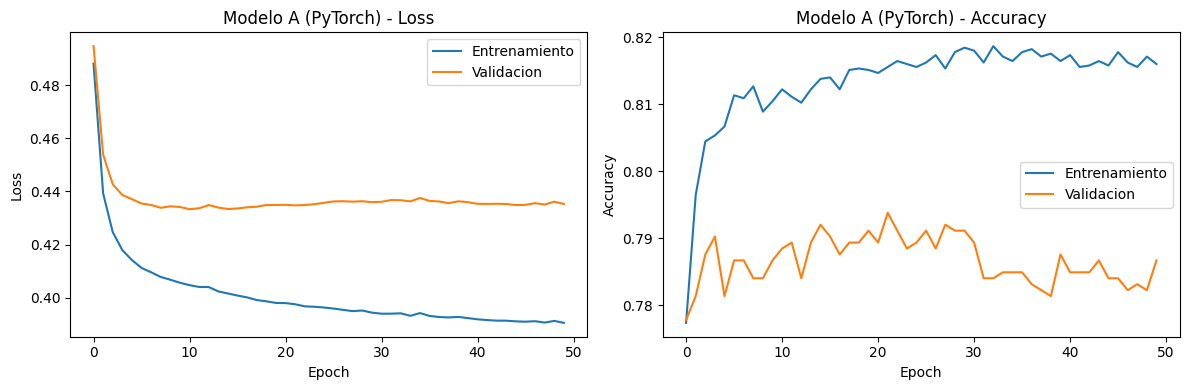

In [11]:
# Graficamos las curvas de entrenamiento, igual que hicimos con Keras
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["loss"], label="Entrenamiento")
axes[0].plot(history["val_loss"], label="Validacion")
axes[0].set_title("Modelo A (PyTorch) - Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history["accuracy"], label="Entrenamiento")
axes[1].plot(history["val_accuracy"], label="Validacion")
axes[1].set_title("Modelo A (PyTorch) - Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


In [12]:
# Evaluamos el modelo sobre el conjunto de test
modelo_a_torch.eval()
with torch.no_grad():
    pred_test = modelo_a_torch(X_test_tensor).squeeze()
    loss_test = criterio(pred_test, y_test_tensor).item()
    acc_test = calcular_accuracy(pred_test, y_test_tensor)

print("Modelo A (PyTorch) - Loss en test:", loss_test)
print("Modelo A (PyTorch) - Accuracy en test:", acc_test)


Modelo A (PyTorch) - Loss en test: 0.43565887212753296
Modelo A (PyTorch) - Accuracy en test: 0.8009950518608093


Estos números deberían ser bastante parecidos a los que obtuvimos con
el Modelo A en Keras (Notebook 1 y 2): la arquitectura es exactamente la
misma, el optimizador es el mismo (Adam), la función de loss es la misma
(binary crossentropy). Pequeñas diferencias son normales, porque el orden en
que se procesan los batches, la inicialización de pesos, y detalles internos
de implementación no son idénticos entre ambas librerías.


## 4. Keras vs PyTorch: qué se parece y qué cambia

| Concepto | Keras | PyTorch |
|---|---|---|
| Definir capas | `Sequential([Dense(...), ...])` | Clase que hereda de `nn.Module`, con `nn.Linear` |
| Forward pass | Automático, definido por el orden de las capas | Explícito, en el método `forward` |
| Loss y optimizador | `model.compile(...)` | Se crean como objetos separados (`nn.BCELoss()`, `optim.Adam(...)`) |
| Entrenamiento | `model.fit(...)` hace todo el loop | Se escribe el loop a mano, epoch por epoch y batch por batch |
| Backpropagation | Oculta dentro de `fit()` | Explícita: `loss.backward()` |
| Actualizar pesos | Oculta dentro de `fit()` | Explícita: `optimizador.step()` |
| Batches | Parámetro `batch_size` | `DataLoader` |

En síntesis:

- **Keras** te da una API de alto nivel: menos código, entrenamiento más
  rápido de escribir, ideal para prototipar rápido y para aprender los
  conceptos de arquitectura sin pelearte con el loop de entrenamiento.
- **PyTorch** te da control explícito sobre cada paso del entrenamiento. Esto
  requiere más código, pero es más flexible para investigación, arquitecturas
  no estándar, y es hoy la librería dominante en la mayoría de los papers de
  investigación y en varios de los laboratorios de IA más importantes.

Lo más importante para llevarse de este notebook: los **conceptos** que
aprendimos en las tres sesiones principales (capas, neuronas, activaciones,
loss, optimizer, epochs, batches, overfitting, Dropout, regularización,
EarlyStopping) no son exclusivos de Keras. Son conceptos universales de Deep
Learning, y se aplican de la misma forma sin importar qué librería uses para
implementarlos. Cambia la sintaxis, no las ideas.
